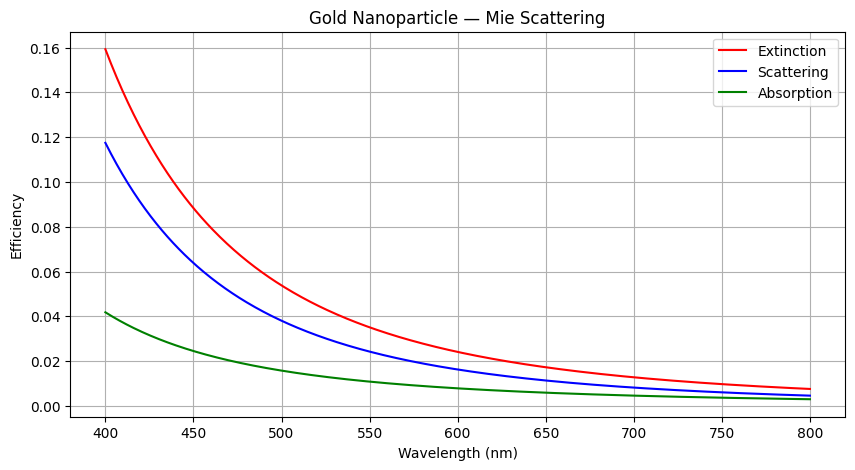

In [5]:
#import scipy.integrate
#scipy.integrate.trapz = scipy.integrate.trapezoid

import PyMieScatt as ps
import numpy as np
import matplotlib.pyplot as plt


# Gold nanoparticle — 50nm diameter
diameter = 50e-9
wavelengths = np.linspace(400e-9, 800e-9, 500)

# Gold refractive index (approximate)
def gold_n(wl):
    wl_nm = wl * 1e9
    n = 0.142 + 1j * (wl_nm / 100)
    return n

scattering = []
absorption = []
extinction = []

for wl in wavelengths:
    m = gold_n(wl)
    result = ps.MieQ(m, wl*1e9, diameter*1e9)
    extinction.append(result[0])
    scattering.append(result[1])
    absorption.append(result[2])

plt.figure(figsize=(10, 5))
plt.plot(wavelengths*1e9, extinction, 'r-', label='Extinction')
plt.plot(wavelengths*1e9, scattering, 'b-', label='Scattering')
plt.plot(wavelengths*1e9, absorption, 'g-', label='Absorption')
plt.title("Gold Nanoparticle — Mie Scattering")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Efficiency")
plt.legend()
plt.grid(True)
plt.show()

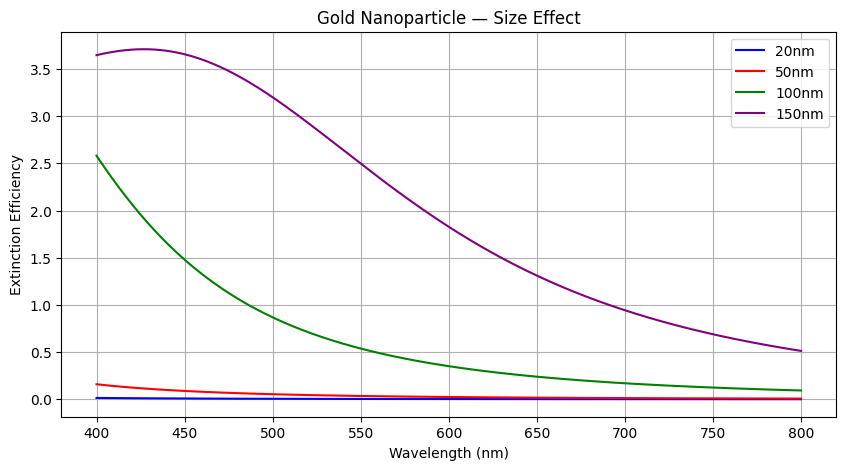

In [6]:
sizes = [20, 50, 100, 150]
colors = ['blue', 'red', 'green', 'purple']

plt.figure(figsize=(10, 5))
for d, color in zip(sizes, colors):
    ext = []
    for wl in wavelengths:
        m = gold_n(wl)
        result = ps.MieQ(m, wl*1e9, d)
        ext.append(result[0])
    plt.plot(wavelengths*1e9, ext, color=color, label=f'{d}nm')

plt.title("Gold Nanoparticle — Size Effect")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Extinction Efficiency")
plt.legend()
plt.grid(True)
plt.show()

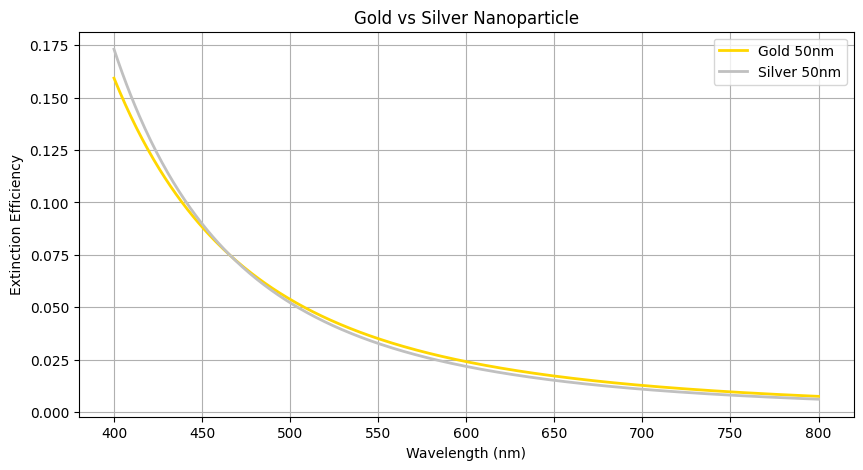

In [8]:
# Silver nanoparticle compare
def silver_n(wl):
    wl_nm = wl * 1e9
    n = 0.05 + 1j * (wl_nm / 120)
    return n

ext_gold = []
ext_silver = []

for wl in wavelengths:
    mg = gold_n(wl)
    ms = silver_n(wl)
    ext_gold.append(ps.MieQ(mg, wl*1e9, 50)[0])
    ext_silver.append(ps.MieQ(ms, wl*1e9, 50)[0])

plt.figure(figsize=(10, 5))
plt.plot(wavelengths*1e9, ext_gold, 'gold', linewidth=2, label='Gold 50nm')
plt.plot(wavelengths*1e9, ext_silver, 'silver', linewidth=2, label='Silver 50nm')
plt.title("Gold vs Silver Nanoparticle")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Extinction Efficiency")
plt.legend()
plt.grid(True)
plt.show()